# 1. Import Libraries, Configuration Setup, and Load the Dataset

## 1.1 Install \& Import Libraries

In [1]:
# !pip install peft==0.13.2, transformers==4.41.1

In [2]:
# !pip install wordcloud

In [3]:
# !pip install imblearn

In [4]:
# !pip install lightgbm

In [5]:
# ── Standard library ─────────────────────────────────────
import os
import re
import gc
import json
import time
import random
import warnings
from pathlib import Path
from typing import Any, Dict, Tuple, Optional

# ── Core DS stack ────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# ── Scikit-learn ─────────────────────────────────────────
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix,
    f1_score, roc_curve, auc, accuracy_score,
)
from sklearn.utils import resample, shuffle

# ── PyTorch ──────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR

# ── Transformers ─────────────────────────────────────────
from transformers import (
    AutoConfig,
    AlbertForSequenceClassification, AutoModelForSequenceClassification,
    AutoTokenizer, )

# ── Notebook setup ───────────────────────────────────────
warnings.filterwarnings("ignore")


## 1.2 Seed \& Device

In [6]:
# One notebook copy per training seed. Change RUN_SEED only.
RUN_SEED = 2025

# Fixed R0 data constant, independent of the training seed.
SPLIT_SHUFFLE_SEED = 2025

SEED = RUN_SEED

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Run seed: {RUN_SEED} | split shuffle: {SPLIT_SHUFFLE_SEED} | Device: {DEVICE}")


Run seed: 2025 | split shuffle: 2025 | Device: cuda


## 1.3 Configuration

In [7]:
DRIVE_PROJECT_PATH = "./04_SoftLabel_TrainOnly"
RAW_DATA_FILE = "data/mental_health_unified_labels_final.csv"
OUTPUT_DIR = "outputs"

ALBERT_MODEL_NAME = "albert-base-v2"
BIOBERT_MODEL_NAME = "dmis-lab/biobert-v1.1"

TEXT_COLUMN = "statement"

# ── 7-class mental health ────────────────────────────────
CLASS_NAMES = ["SUICIDAL", "DEPRESSION", "STRESS", "ANXIETY", "NORMAL", "BIPOLAR", "PERSONALITY_DISORDER"]
NUM_CLASSES = len(CLASS_NAMES)

# ── Soft-label columns (already in CSV) ─────────────────
SOFT_COLS = ["u_p_suicidal", "u_p_depression", "u_p_stress", "u_p_anxiety", "u_p_normal", "u_p_bipolar", "u_p_personality_disorder"]
LABEL_COLUMN = "u_label"
SPECIAL_LABELS = {"OUT_OF_SCOPE", "INSUFFICIENT"}
LABEL_MAP = {name: i for i, name in enumerate(CLASS_NAMES)}

# ── Training config ──────────────────────────────────────
MAX_TOKEN_LENGTH = 200
BATCH_SIZE = 128

RANDOM_STATE = 42
PATIENCE = 3
NUM_WORKERS = 2   # same as the R0 hard transformer loaders

# ── A100 optimizations ──────────────────────────────────



# ── Retrain flag ─────────────────────────────────────────
# R0 hard-style transformer random search. Same search budget and ranges as R0 hard.
N_ITERATIONS = 10
TRANSFORMER_PARAM_SPACE = {
    "lr": (np.log10(1e-5), np.log10(3e-5)),
    "epochs": (4, 10),
    "dropout": (0.0, 0.25),
}

# Reviewer-requested matching (TAFFC R1, Reviewer 1 point 3): adopt the R0 HARD
# optimizer settings so only the target and its loss differ from the hard arm.
USE_FP16 = torch.cuda.is_available()
USE_COMPILE = hasattr(torch, "compile") and torch.cuda.is_available()  # R0 hard used compile
USE_ONECYCLE = True
ONECYCLE_PCT_START = 0.1
MAX_GRAD_NORM = 1.0

RETRAIN = True

# ── Derived paths ────────────────────────────────────────
RAW_DATA_PATH = os.path.join(DRIVE_PROJECT_PATH, RAW_DATA_FILE)
OUTPUT_PATH = Path(DRIVE_PROJECT_PATH) / OUTPUT_DIR
OUTPUT_PATH.mkdir(parents=True, exist_ok=True)

MODEL_PATHS = {
    "albert": {
        "model":  OUTPUT_PATH / "best_albert_soft_train.pth",
        "params": OUTPUT_PATH / "best_albert_soft_train_params.json",
    },
    "biobert": {
        "model":  OUTPUT_PATH / "best_biobert_soft_train.pth",
        "params": OUTPUT_PATH / "best_biobert_soft_train_params.json",
    },
}

print("--- 7-Class Soft-Label Configuration (Mental Health) ---")
print(f"  Project    : {DRIVE_PROJECT_PATH}")
print(f"  Classes    : {CLASS_NAMES}")
print(f"  Soft cols  : {SOFT_COLS}")
print(f"  Label col  : {LABEL_COLUMN}")

--- 7-Class Soft-Label Configuration (Mental Health) ---
  Project    : ./04_SoftLabel_TrainOnly
  Classes    : ['SUICIDAL', 'DEPRESSION', 'STRESS', 'ANXIETY', 'NORMAL', 'BIPOLAR', 'PERSONALITY_DISORDER']
  Soft cols  : ['u_p_suicidal', 'u_p_depression', 'u_p_stress', 'u_p_anxiety', 'u_p_normal', 'u_p_bipolar', 'u_p_personality_disorder']
  Label col  : u_label


## 1.4 Mount drive & Load the data

In [8]:
import os
if os.path.ismount("/content/drive"):
    # Already mounted, skip
    pass
else:
    !fusermount -u /content/drive 2>/dev/null
    !rm -rf /content/drive/*
    from google.colab import drive
    drive.mount("/content/drive/", force_remount=True)

df_raw = pd.read_csv(RAW_DATA_PATH, index_col=0)
print(f"Loaded {df_raw.shape[0]} rows.")
df_raw.head()


Mounted at /content/drive/
Loaded 53043 rows.


,statement,status,u_label,u_p_normal,u_p_depression,u_p_anxiety,u_p_suicidal,u_p_stress,u_p_bipolar,u_p_personality_disorder,...,u_model_version,u_system_fingerprint,u_annotation_timestamp,u_raw_json,u_n_conditions,u_any_clinical,u_normal_inferred,u_multilabel,u_max_clinical_prob,u_sum_clinical_prob
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
0,oh my gosh,Anxiety,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",0,False,True,NORMAL,0.0,0.0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
3,I've shifted my focus to something else but I'...,Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
4,"I'm restless and restless, it's been a month n...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0


In [9]:
# ── SCOPE GATE: keep only evaluable posts ────────────────
before = len(df_raw)
df_raw = df_raw[~df_raw[LABEL_COLUMN].isin(SPECIAL_LABELS)].reset_index(drop=True)
print(f"Scope gating: {before} → {len(df_raw)} rows "
      f"(removed {before - len(df_raw)} OUT_OF_SCOPE/INSUFFICIENT)")
df_raw.head()

Scope gating: 53043 → 53043 rows (removed 0 OUT_OF_SCOPE/INSUFFICIENT)


,statement,status,u_label,u_p_normal,u_p_depression,u_p_anxiety,u_p_suicidal,u_p_stress,u_p_bipolar,u_p_personality_disorder,...,u_model_version,u_system_fingerprint,u_annotation_timestamp,u_raw_json,u_n_conditions,u_any_clinical,u_normal_inferred,u_multilabel,u_max_clinical_prob,u_sum_clinical_prob
0,oh my gosh,Anxiety,NORMAL,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",0,False,True,NORMAL,0.0,0.0
1,"trouble sleeping, confused mind, restless hear...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
3,I've shifted my focus to something else but I'...,Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0
4,"I'm restless and restless, it's been a month n...",Anxiety,ANXIETY,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,gpt-4o-mini-2024-07-18,fp_373a14eb6f,2026-02-27T18:17:03.262768,"[\n {\n ""index"": 0,\n ""label"": ""NORMAL""...",1,True,False,ANXIETY,1.0,1.0


In [10]:
# Fixed R0 data constant. Must not follow RUN_SEED.
df_raw = shuffle(df_raw, random_state=SPLIT_SHUFFLE_SEED).reset_index(drop=True)


In [11]:
print(f"Loaded {df_raw.shape[0]} rows.")

Loaded 53043 rows.


# 2. Data Exploration \& Master Data Preparation

## 2.1 Master Data Preparation

### 2.1.1 Text cleaning

In [12]:
def clean_text(text: str) -> str:
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r"http\S+", " urltoken ", text)
    text = re.sub(r"@\w+", " usertoken ", text)
    text = re.sub(r"#(\w+)", r" hashtag_\1 ", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()


print("Cleaning text...")
df_clean = df_raw.copy()
df_clean[TEXT_COLUMN] = df_clean[TEXT_COLUMN].apply(clean_text)

Cleaning text...


In [13]:
print(f"Loaded {df_clean.shape[0]} rows.")

Loaded 53043 rows.


### 2.1.2 Validate soft labels

In [14]:
print("\nValidating soft-label probability columns...")
for col in SOFT_COLS:
    if col not in df_clean.columns:
        raise ValueError(f"Missing column: {col}")
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").fillna(0.0)

# Validate rows sum to ~1
row_sums = df_clean[SOFT_COLS].sum(axis=1)
print(f"  Probability row sums — min: {row_sums.min():.4f}, max: {row_sums.max():.4f}, mean: {row_sums.mean():.4f}")

# Normalize to ensure sum = 1
soft_array = df_clean[SOFT_COLS].to_numpy(dtype=np.float32)
soft_array = soft_array / np.clip(soft_array.sum(axis=1, keepdims=True), 1e-8, None)

for i, col in enumerate(SOFT_COLS):
    df_clean[col] = soft_array[:, i]

# Hard label = the protocol label u_label (not the soft-vector argmax)
df_clean["y_hard"] = df_clean[LABEL_COLUMN].map(LABEL_MAP).astype(int)

print(f"\ny_hard distribution (from u_label):")
print(df_clean["y_hard"].map({i: name for i, name in enumerate(CLASS_NAMES)}).value_counts())



Validating soft-label probability columns...
  Probability row sums — min: 0.4000, max: 4.0000, mean: 1.0038

y_hard distribution (from u_label):
y_hard
NORMAL                  19921
SUICIDAL                12145
DEPRESSION               9688
ANXIETY                  7550
STRESS                   2119
BIPOLAR                  1213
PERSONALITY_DISORDER      407
Name: count, dtype: int64


### 2.1.3 Soft-label analysis

In [15]:
print("\nSoft label statistics:")
print(f"  Shape: {soft_array.shape}")
print(f"  Min: {soft_array.min():.4f}, Max: {soft_array.max():.4f}")

# Entropy analysis
hard = soft_array.argmax(axis=1)
for i, name in enumerate(CLASS_NAMES):
    mask = (hard == i)
    if mask.sum() == 0:
        continue
    class_soft = soft_array[mask]
    own_prob = class_soft[:, i].mean()
    entropy = -(class_soft * np.log(np.clip(class_soft, 1e-8, 1))).sum(axis=1).mean()
    print(f"{name:25s} | n={mask.sum():5d} | own_prob={own_prob:.3f} | entropy={entropy:.3f}")


Soft label statistics:
  Shape: (53043, 7)
  Min: 0.0000, Max: 1.0000
SUICIDAL                  | n=12127 | own_prob=0.898 | entropy=0.226
DEPRESSION                | n= 9798 | own_prob=0.850 | entropy=0.349
STRESS                    | n= 2256 | own_prob=0.915 | entropy=0.190
ANXIETY                   | n= 7478 | own_prob=0.842 | entropy=0.412
NORMAL                    | n=19831 | own_prob=0.937 | entropy=0.175
BIPOLAR                   | n= 1162 | own_prob=0.912 | entropy=0.220
PERSONALITY_DISORDER      | n=  391 | own_prob=0.923 | entropy=0.196


## 2.2 Master Data Split

In [16]:
groups = df_clean[TEXT_COLUMN]
y_for_split = df_clean["y_hard"]

# 80/20 → train+val / test
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
trainval_idx, test_idx = next(gss_test.split(df_clean, y_for_split, groups=groups))

split = np.full(len(df_clean), "train", dtype=object)
split[test_idx] = "test"

# train → train + val (75/25 of 80% = 60/20)
df_trainval = df_clean.iloc[trainval_idx].copy().reset_index(drop=True)
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_STATE)
train_idx2, val_idx = next(
    gss_val.split(df_trainval, df_trainval["y_hard"],
                  groups=df_trainval[TEXT_COLUMN])
)
split[trainval_idx[val_idx]] = "val"
df_clean["split"] = split
# Stable identifier for pairing predictions across notebooks. Cleaned text is
# not unique (10,550 test rows share 10,194 distinct cleaned statements), so a
# merge on text alone is unsafe.
df_clean["id"] = np.arange(len(df_clean), dtype=np.int64)

print("\nSplit counts:")
print(df_clean["split"].value_counts())

# Leakage check
group_split_nunique = df_clean.groupby(TEXT_COLUMN)["split"].nunique()
n_leaky = (group_split_nunique > 1).sum()
assert n_leaky == 0, f"{n_leaky} text groups leak across splits!"
print("Leakage check passed.")

# Save
split_path = OUTPUT_PATH / "master_split_soft_train.csv"
df_clean.to_csv(split_path, index=False)
print(f"Saved master split → {split_path}")


Split counts:
split
train    31976
test     10550
val      10517
Name: count, dtype: int64
Leakage check passed.
Saved master split → ./04_SoftLabel_TrainOnly/outputs/master_split_soft_train.csv


# 3. ALBERT \& BioBERT Models (soft training \& hard validation + test)

## 3.1 Shared helper functions

In [17]:
def bootstrap_f1_ci(y_true, y_pred, n_iterations=1000, average="weighted"):
    """Return the OBSERVED F1 on the full test set plus a bootstrap 95% CI.

    The first element is the direct point estimate, not the mean of the
    bootstrap replicates; replicates are used only for the interval.
    """
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    observed = f1_score(y_true, y_pred, average=average)
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(f1_score(y_true[idx], y_pred[idx], average=average))
        except ValueError:
            continue
    if not scores:
        return observed, np.nan, np.nan
    return observed, np.percentile(scores, 2.5), np.percentile(scores, 97.5)


def bootstrap_auc_ci(y_true, y_scores, n_iterations=1000, average="macro"):
    """Observed macro AUC plus a bootstrap 95% CI (point estimate is direct)."""
    y_true, y_scores = np.asarray(y_true), np.asarray(y_scores)
    try:
        observed = roc_auc_score(y_true, y_scores, average=average, multi_class="ovr")
    except Exception:
        observed = np.nan
    scores = []
    for _ in range(n_iterations):
        idx = resample(np.arange(len(y_true)))
        try:
            scores.append(
                roc_auc_score(y_true[idx], y_scores[idx], average=average, multi_class="ovr")
            )
        except ValueError:
            continue
    if not scores:
        return observed, np.nan, np.nan
    return observed, np.percentile(scores, 2.5), np.percentile(scores, 97.5)
### 2.4.2 Plotting
def plot_confusion_matrix(y_true, y_pred, labels, title="Model", save_dir=None):
    """Works for both string labels (ML) and int labels (DL)."""
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()

def plot_confusion_matrix(y_true, y_pred, class_names, title="Model", save_dir=None):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"Confusion Matrix — {title}")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_confusion_matrix.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()


def plot_multiclass_roc(y_true, y_score, class_names, title="Model", save_dir=None):
    y_true_bin = label_binarize(np.asarray(y_true, dtype=int),
                                classes=np.arange(len(class_names)))
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(len(class_names)):
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    colors = sns.color_palette("mako", len(class_names))
    plt.figure(figsize=(10, 8))
    for i, (name, color) in enumerate(zip(class_names, colors)):
        plt.plot(fpr[i], tpr[i], color=color, lw=2,
                 label=f"{name} (AUC={roc_auc[i]:.2f})")
    plt.plot([0, 1], [0, 1], "k--", lw=2)
    plt.xlim([0, 1])
    plt.ylim([0, 1.05])
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{title} — Multi-class ROC")
    plt.legend(loc="lower right")
    plt.tight_layout()
    if save_dir:
        os.makedirs(save_dir, exist_ok=True)
        path = os.path.join(save_dir, f"{title}_roc_curve.png")
        plt.savefig(path, dpi=300)
        print(f"Saved → {path}")
    plt.show()

## 3.2 Data splits \& labels

In [18]:
def _extract_soft(df):
    s = df[SOFT_COLS].to_numpy(dtype=np.float32)
    return s / np.clip(s.sum(axis=1, keepdims=True), 1e-8, None)

df_train = df_clean[df_clean["split"] == "train"].copy()
df_val   = df_clean[df_clean["split"] == "val"].copy()
df_test  = df_clean[df_clean["split"] == "test"].copy()

train_texts = df_train[TEXT_COLUMN].astype(str).tolist()
val_texts   = df_val[TEXT_COLUMN].astype(str).tolist()
test_texts  = df_test[TEXT_COLUMN].astype(str).tolist()

# Soft labels for training, hard labels for val/test evaluation
y_train_soft = _extract_soft(df_train)
y_val_hard   = df_val["y_hard"].to_numpy(dtype=np.int64)
y_test_hard  = df_test["y_hard"].to_numpy(dtype=np.int64)

print(f"Train soft: {y_train_soft.shape}")
print(f"Val  hard : {np.bincount(y_val_hard, minlength=NUM_CLASSES)}")
print(f"Test hard : {np.bincount(y_test_hard, minlength=NUM_CLASSES)}")
y_train_hard = df_train["y_hard"].to_numpy(dtype=np.int64)
_counts = np.bincount(y_train_hard, minlength=NUM_CLASSES).astype(np.float64)
assert (_counts > 0).all(), f"empty class in train: {_counts.tolist()}"
CLASS_WEIGHTS_DL = torch.tensor(
    len(y_train_hard) / (NUM_CLASSES * _counts), dtype=torch.float32
).to(DEVICE)
# Unweighted soft cross-entropy, as in the R0 soft-label notebooks.
# Class weighting is not target-neutral: applied to a distributed target it
# amplifies whatever probability mass falls on rare classes, which distorts
# the predicted class distribution. The reviewer asked for scheduler, gradient
# clipping, epoch range and optimizer settings to be matched to the hard arm
# (all of which are), and explicitly allows the target and loss to differ.
SOFT_CLASS_WEIGHTS = None
print("Class weights:", "none" if SOFT_CLASS_WEIGHTS is None
      else [round(float(w), 3) for w in CLASS_WEIGHTS_DL])


Train soft: (31976, 7)
Val  hard : [2468 1936  442 1532 3824  237   78]
Test hard : [2433 1949  427 1510 3897  245   89]
Class weights: none


## 3.3 Generic soft-label model componets

In [19]:
# ── Pre-tokenization ─────────────────────────────────────
def batch_tokenize(texts, tokenizer, max_len):
    enc = tokenizer(
        [str(t) for t in texts],
        truncation=True, padding="max_length",
        max_length=max_len, return_tensors="pt",
    )
    return enc["input_ids"], enc["attention_mask"]


# ── Dataset ──────────────────────────────────────────────
class SoftLabelDataset(Dataset):
    """Pre-tokenized dataset with optional soft and hard labels."""

    def __init__(self, input_ids, attention_masks,
                 hard_labels=None, soft_labels=None):
        self.input_ids = input_ids
        self.attention_masks = attention_masks

        self.soft_labels = None
        if soft_labels is not None:
            sl = np.asarray(soft_labels, dtype=np.float32)
            rs = sl.sum(axis=1, keepdims=True)
            self.soft_labels = sl / np.clip(rs, 1e-8, None)

        self.hard_labels = None
        if hard_labels is not None:
            self.hard_labels = np.asarray(hard_labels, dtype=np.int64)
        elif self.soft_labels is not None:
            self.hard_labels = self.soft_labels.argmax(axis=1).astype(np.int64)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        item = {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_masks[idx],
        }
        if self.hard_labels is not None:
            item["labels"] = torch.tensor(self.hard_labels[idx], dtype=torch.long)
        if self.soft_labels is not None:
            item["soft_labels"] = torch.tensor(self.soft_labels[idx], dtype=torch.float32)
        return item


# ── Classifier ───────────────────────────────────────────
class TransformerClassifier(nn.Module):
    """Wrapper over the HuggingFace sequence-classification head used by R0 hard.

    Keeps the (input_ids, attention_mask) -> logits call signature so the rest of
    this notebook is unchanged, while the head itself now matches the R0 hard arm
    (AlbertForSequenceClassification / AutoModelForSequenceClassification).
    """

    def __init__(self, hf_model):
        super().__init__()
        self.model = hf_model

    def forward(self, input_ids, attention_mask):
        out = self.model(input_ids=input_ids, attention_mask=attention_mask)
        return out.logits if hasattr(out, "logits") else out


# ── Loss function ────────────────────────────────────────
def weighted_soft_cross_entropy(logits, soft_targets, class_weights=None):
    """Soft-label CE with R0-hard-compatible weighted-mean reduction."""
    log_probs = torch.log_softmax(logits, dim=1)
    if class_weights is None:
        return -(soft_targets * log_probs).sum(dim=1).mean()
    w = class_weights.to(logits.device).float().view(1, -1)
    weighted = soft_targets * w
    num = -(weighted * log_probs).sum()
    den = weighted.sum().clamp_min(torch.finfo(torch.float32).eps)
    return num / den


# ── Inference helper ─────────────────────────────────────
def predict_logits(model, loader, device=DEVICE):
    """Run inference, return (logits, hard_labels, soft_labels) as numpy."""
    model.eval()
    all_logits, all_labels, all_soft = [], [], []
    with torch.no_grad():
        for batch in loader:
            ids = batch["input_ids"].to(device, non_blocking=True)
            mask = batch["attention_mask"].to(device, non_blocking=True)

            with torch.autocast("cuda", dtype=torch.float16, enabled=USE_FP16):
                logits = model(ids, mask)

            all_logits.append(logits.float().cpu().numpy())
            if "labels" in batch:
                all_labels.append(batch["labels"].numpy())
            if "soft_labels" in batch:
                all_soft.append(batch["soft_labels"].numpy())
    return (
        np.concatenate(all_logits),
        np.concatenate(all_labels) if all_labels else None,
        np.concatenate(all_soft) if all_soft else None,
    )


# ── Training function ────────────────────────────────────
def train_soft_model(model, train_loader, val_loader,
                     lr=2e-5, max_epochs=6, patience=PATIENCE):
    """Train with soft CE + BF16 autocast.
    Best epoch selected by val weighted F1. Early stopping."""
    model.to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = max_epochs * len(train_loader)
    scheduler = (OneCycleLR(optimizer, max_lr=lr, total_steps=total_steps,
                            pct_start=ONECYCLE_PCT_START) if USE_ONECYCLE else None)
    scaler = torch.cuda.amp.GradScaler(enabled=USE_FP16)

    best_f1, best_state = -1.0, None
    no_improve = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        losses = []
        for batch in train_loader:
            ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
            mask = batch["attention_mask"].to(DEVICE, non_blocking=True)
            soft = batch["soft_labels"].to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            with torch.autocast("cuda", dtype=torch.float16, enabled=USE_FP16):
                logits = model(ids, mask)
                loss = weighted_soft_cross_entropy(logits, soft, SOFT_CLASS_WEIGHTS)

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(model.parameters(), MAX_GRAD_NORM)

            scaler.step(optimizer)

            scaler.update()

            if scheduler is not None:

                scheduler.step()
            losses.append(loss.item())

        # Validate (hard argmax F1)
        model.eval()
        val_preds, val_true = [], []
        with torch.no_grad():
            for batch in val_loader:
                ids  = batch["input_ids"].to(DEVICE, non_blocking=True)
                mask = batch["attention_mask"].to(DEVICE, non_blocking=True)

                with torch.autocast("cuda", dtype=torch.float16, enabled=USE_FP16):
                    logits = model(ids, mask)

                val_preds.extend(logits.float().argmax(dim=1).cpu().numpy())
                val_true.extend(batch["labels"].numpy())

        val_f1 = f1_score(val_true, val_preds, average="weighted")
        print(f"  Epoch {epoch}/{max_epochs} | Loss={np.mean(losses):.4f} | Val F1={val_f1:.4f}")

        if val_f1 > best_f1:
            best_f1 = val_f1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f"  Early stopping at epoch {epoch}.")
                break

    if best_state:
        model.load_state_dict(best_state)
    return best_f1, model

# ── Evaluation function ──────────────────────────────────
def evaluate_with_ci(model, test_loader, model_name, save_dir=None):
    """Evaluate on test set with bootstrap CIs, plots."""
    logits, y_true, _ = predict_logits(model, test_loader, DEVICE)
    probs = torch.softmax(torch.tensor(logits), dim=1).numpy()
    preds = probs.argmax(axis=1)

    print(f"\n--- {model_name} Test Evaluation ({NUM_CLASSES}-class) ---")
    print(classification_report(
        y_true, preds,
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES, digits=4, zero_division=0,
    ))

    f1_m, f1_lo, f1_hi = bootstrap_f1_ci(y_true, preds)
    print(f"Weighted F1: {f1_m:.4f}  95% CI [{f1_lo:.4f}, {f1_hi:.4f}]")

    f1_mac, f1_mac_lo, f1_mac_hi = bootstrap_f1_ci(y_true, preds, average="macro")
    print(f"Macro F1:    {f1_mac:.4f}  95% CI [{f1_mac_lo:.4f}, {f1_mac_hi:.4f}]")

    auc_m, auc_lo, auc_hi = bootstrap_auc_ci(y_true, probs)
    print(f"Macro AUC:   {auc_m:.4f}  95% CI [{auc_lo:.4f}, {auc_hi:.4f}]")

    plot_confusion_matrix(y_true, preds, CLASS_NAMES,
                          title=f"{model_name}_SoftTrain", save_dir=save_dir)
    plot_multiclass_roc(y_true, probs, CLASS_NAMES,
                        title=f"{model_name}_SoftTrain", save_dir=save_dir)

    return {
        "y_true": y_true, "y_pred": preds, "y_prob": probs,
        "f1_weighted": f1_m, "f1_ci": (f1_lo, f1_hi),
        "f1_macro": f1_mac, "f1_macro_ci": (f1_mac_lo, f1_mac_hi),
        "auc_macro": auc_m, "auc_ci": (auc_lo, auc_hi),
    }

def build_loaders(tokenizer, model_label):
    """Tokenize and build train/val/test loaders."""
    print(f"\nTokenizing for {model_label}...")
    train_ids, train_masks = batch_tokenize(train_texts, tokenizer, MAX_TOKEN_LENGTH)
    val_ids, val_masks     = batch_tokenize(val_texts, tokenizer, MAX_TOKEN_LENGTH)
    test_ids, test_masks   = batch_tokenize(test_texts, tokenizer, MAX_TOKEN_LENGTH)

    loader_kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
                     pin_memory=True, persistent_workers=True, prefetch_factor=4)

    train_loader = DataLoader(
        SoftLabelDataset(train_ids, train_masks, soft_labels=y_train_soft),
        shuffle=True, **loader_kw)
    val_loader = DataLoader(
        SoftLabelDataset(val_ids, val_masks, hard_labels=y_val_hard),
        shuffle=False, **loader_kw)
    test_loader = DataLoader(
        SoftLabelDataset(test_ids, test_masks, hard_labels=y_test_hard),
        shuffle=False, **loader_kw)

    return train_loader, val_loader, test_loader

def dropout_report(module):
    """Map every instantiated nn.Dropout to its probability.

    Reporting the full named map avoids guessing which layer matters: ALBERT's
    backbone dropout is 0.0 while its classifier dropout carries the sampled
    value, and the aspect head's dropout is separate from the encoder's.
    """
    report = {}
    for name, m in module.named_modules():
        if isinstance(m, nn.Dropout):
            report[name or "<root>"] = float(m.p)
    return report


def sampled_dropout_effective(module):
    """The dropout the sampled hyperparameter is meant to control.

    In AlbertForSequenceClassification the classifier dropout module is the
    top-level ``dropout`` (the backbone's own dropout is 0.0), so prefer the
    shallowest module whose name ends in "dropout"; fall back to the deepest
    encoder dropout only if no top-level one exists.
    """
    report = dropout_report(module)
    if not report:
        return None
    named = sorted(report.items(), key=lambda kv: (kv[0].count("."), len(kv[0])))
    for name, p in named:
        if "classifier" in name.lower():
            return p
    for name, p in named:
        if name.split(".")[-1].lower() == "dropout":
            return p
    return named[0][1]


## 3.4 ALBERT: Soft-label training

In [20]:
print("\n" + "=" * 60)
print("ALBERT — Soft-Label Training (Mental Health)")
print("=" * 60)


ALBERT — Soft-Label Training (Mental Health)


### 3.4.1 Pre-tokenize

In [21]:
albert_tokenizer = AutoTokenizer.from_pretrained(ALBERT_MODEL_NAME)
train_loader_albert, val_loader_albert, test_loader_albert = \
    build_loaders(albert_tokenizer, "ALBERT")

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/760k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.31M [00:00<?, ?B/s]


Tokenizing for ALBERT...


### 3.4.2 Hyperparameter tuning

In [22]:
if RETRAIN:
    set_seed(RUN_SEED)
    start = time.time()

    best_f1_albert, best_params_albert, best_albert = -1.0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="ALBERT SoftTrainOnly random search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*TRANSFORMER_PARAM_SPACE["lr"])),
            "epochs": int(np.random.randint(*TRANSFORMER_PARAM_SPACE["epochs"])),
            "dropout": float(np.random.uniform(*TRANSFORMER_PARAM_SPACE["dropout"])),
        }
        print(f"ALBERT trial {i + 1}/{N_ITERATIONS}: {hp}")

        hf = AlbertForSequenceClassification.from_pretrained(
            ALBERT_MODEL_NAME, num_labels=NUM_CLASSES,
            classifier_dropout_prob=hp["dropout"],
        )
        hp["dropout_modules"] = dropout_report(hf)
        if USE_COMPILE:
            hf = torch.compile(hf, mode="reduce-overhead")
        model = TransformerClassifier(hf)

        f1_val, model = train_soft_model(
            model, train_loader_albert, val_loader_albert,
            lr=hp["lr"], max_epochs=hp["epochs"],
        )

        if f1_val > best_f1_albert:
            best_f1_albert = f1_val
            best_params_albert = {"seed": RUN_SEED, "trial": i + 1, **hp}
            best_albert = model
            torch.save(model.state_dict(), MODEL_PATHS["albert"]["model"])
            with open(MODEL_PATHS["albert"]["params"], "w") as _pf:
                json.dump(best_params_albert, _pf, indent=2)
            print(f"  New best ALBERT: ValF1={f1_val:.4f}")

        gc.collect()
        torch.cuda.empty_cache()

    print(f"ALBERT random search: {time.time()-start:.1f}s | Best F1={best_f1_albert:.4f}")
    print(f"Best params: {best_params_albert}")

    with open(MODEL_PATHS["albert"]["params"], "w") as f:
        json.dump(best_params_albert, f, indent=2)

else:
    with open(MODEL_PATHS["albert"]["params"]) as f:
        best_params_albert = json.load(f)
    hf = AlbertForSequenceClassification.from_pretrained(
        ALBERT_MODEL_NAME, num_labels=NUM_CLASSES,
        classifier_dropout_prob=best_params_albert["dropout"],
    )
    if USE_COMPILE:
        hf = torch.compile(hf, mode="reduce-overhead")
    best_albert = TransformerClassifier(hf)
    best_albert.load_state_dict(torch.load(MODEL_PATHS["albert"]["model"], map_location=DEVICE))

best_albert.to(DEVICE)
best_albert.eval()


ALBERT SoftTrainOnly random search:   0%|          | 0/10 [00:00<?, ?it/s]

ALBERT trial 1/10: {'lr': 1.160497696239576e-05, 'epochs': 6, 'dropout': 0.08535068283342875}


model.safetensors: reconstructing file:   0%|          |  0.00B / 47.4MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/25 [00:00<?, ?it/s]

...

[transformers] AlbertForSequenceClassification LOAD REPORT from: albert-base-v2
Key                          | Status     | 
-----------------------------+------------+-
predictions.dense.weight     | UNEXPECTED | 
predictions.decoder.bias     | UNEXPECTED | 
predictions.bias             | UNEXPECTED | 
predictions.dense.bias       | UNEXPECTED | 
predictions.LayerNorm.bias   | UNEXPECTED | 
predictions.LayerNorm.weight | UNEXPECTED | 
classifier.weight            | MISSING    | 
classifier.bias              | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=1.2427 | Val F1=0.7575
  Epoch 2/9 | Loss=0.8471 | Val F1=0.7851
  Epoch 3/9 | Loss=0.7532 | Val F1=0.7954
  Epoch 4/9 | Loss=0.6822 | Val F1=0.7960
  Epoch 5/9 | Loss=0.6079 | Val F1=0.8012
  Epoch 6/9 | Loss=0.5298 | Val F1=0.7961
  Epoch 7/9 | Loss=0.4656 | Val F1=0.7962
  Epoch 8/9 | Loss=0.4265 | Val F1=0.7930
  Early stopping at epoch 8.


ALBERT SoftTrainOnly random search: 100%|██████████| 10/10 [57:18<00:00, 343.89s/it]

ALBERT random search: 3438.9s | Best F1=0.8023
Best params: {'seed': 2025, 'trial': 8, 'lr': 1.0897647295667571e-05, 'epochs': 7, 'dropout': 0.06214965916767748, 'dropout_modules': {'albert.embeddings.dropout': 0.0, 'albert.encoder.albert_layer_groups.0.albert_layers.0.attention.attention_dropout': 0.0, 'albert.encoder.albert_layer_groups.0.albert_layers.0.attention.output_dropout': 0.0, 'albert.encoder.albert_layer_groups.0.albert_layers.0.dropout': 0.0, 'dropout': 0.06214965916767748}}


TransformerClassifier(
  (model): OptimizedModule(
    (_orig_mod): AlbertForSequenceClassification(
      (albert): AlbertModel(
        (embeddings): AlbertEmbeddings(
          (word_embeddings): Embedding(30000, 128, padding_idx=0)
          (position_embeddings): Embedding(512, 128)
          (token_type_embeddings): Embedding(2, 128)
          (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0, inplace=False)
        )
        (encoder): AlbertTransformer(
          (embedding_hidden_mapping_in): Linear(in_features=128, out_features=768, bias=True)
          (albert_layer_groups): ModuleList(
            (0): AlbertLayerGroup(
              (albert_layers): ModuleList(
                (0): AlbertLayer(
                  (full_layer_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
                  (attention): AlbertAttention(
                    (attention_dropout): Dropout(p=0, inplace=False)
                   

### 3.4.3 Model evaluation


--- ALBERT Test Evaluation (7-class) ---
                      precision    recall  f1-score   support

            SUICIDAL     0.8471    0.8200    0.8333      2433
          DEPRESSION     0.6739    0.7347    0.7030      1949
              STRESS     0.5462    0.4426    0.4890       427
             ANXIETY     0.8177    0.7219    0.7668      1510
              NORMAL     0.8438    0.8968    0.8695      3897
             BIPOLAR     0.7229    0.7347    0.7287       245
PERSONALITY_DISORDER     0.0000    0.0000    0.0000        89

            accuracy                         0.7944     10550
           macro avg     0.6360    0.6215    0.6272     10550
        weighted avg     0.7875    0.7944    0.7897     10550

Weighted F1: 0.7897  95% CI [0.7819, 0.7977]
Macro F1:    0.6272  95% CI [0.6156, 0.6373]
Macro AUC:   0.9498  95% CI [0.9451, 0.9542]
Saved → ./04_SoftLabel_TrainOnly/outputs/ALBERT_SoftTrain_confusion_matrix.png


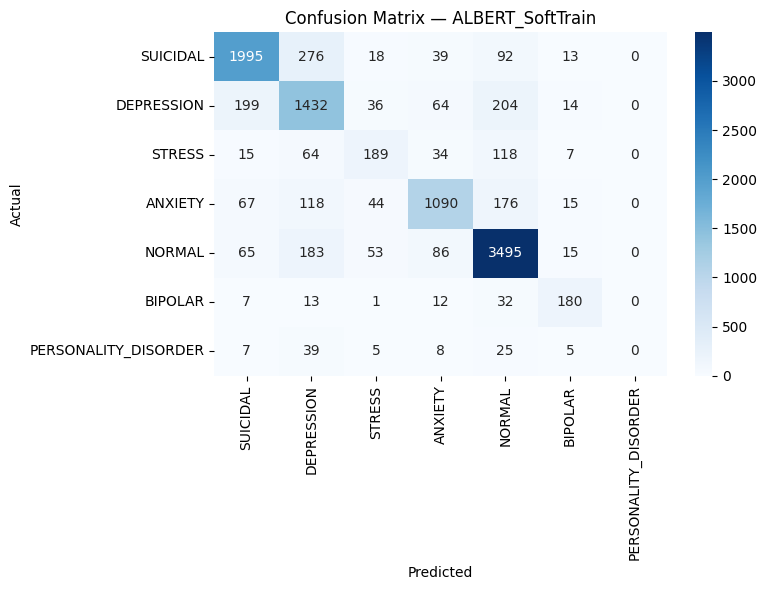

Saved → ./04_SoftLabel_TrainOnly/outputs/ALBERT_SoftTrain_roc_curve.png


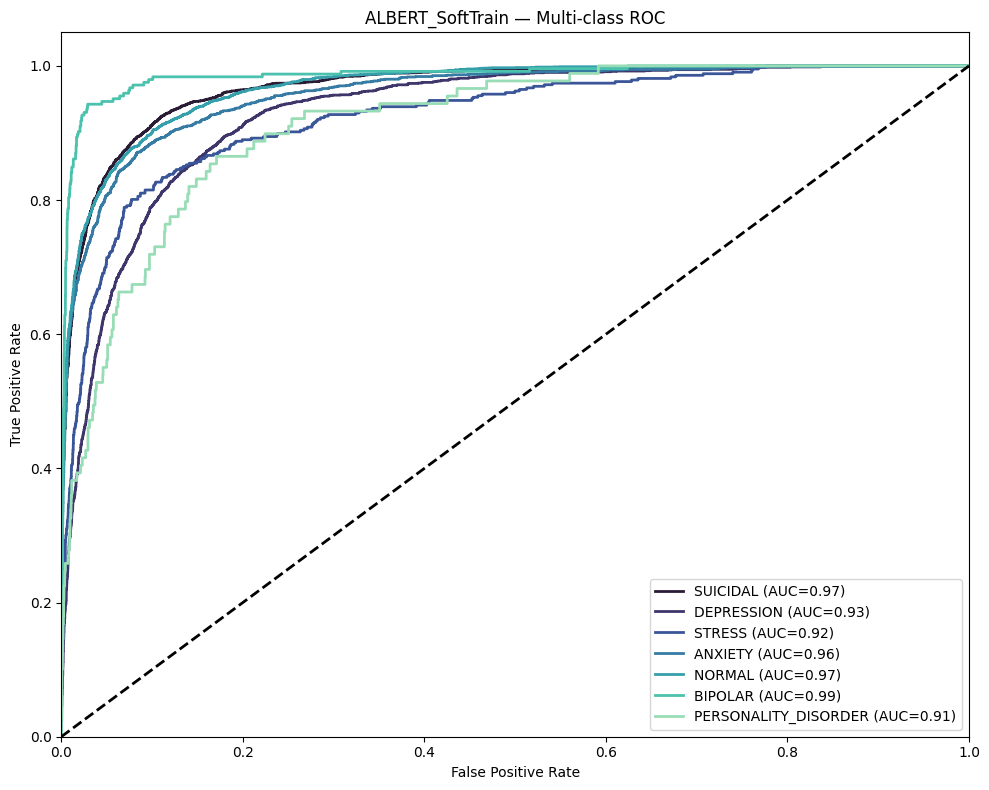

In [23]:
albert_results = evaluate_with_ci(
    best_albert, test_loader_albert, "ALBERT", save_dir=str(OUTPUT_PATH)
)

## 3.5 BioBERT: Soft-label training

In [24]:
print("\n" + "=" * 60)
print("BioBERT — Soft-Label Training (Mental Health)")
print("=" * 60)


BioBERT — Soft-Label Training (Mental Health)


### 3.5.1 Pre-tokenize

In [25]:
biobert_tokenizer = AutoTokenizer.from_pretrained(BIOBERT_MODEL_NAME)
train_loader_biobert, val_loader_biobert, test_loader_biobert = \
    build_loaders(biobert_tokenizer, "BioBERT")

config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]


Tokenizing for BioBERT...


### 3.5.2 Hyperparameter tuning

In [26]:
if RETRAIN:
    set_seed(RUN_SEED)
    start = time.time()

    best_f1_biobert, best_params_biobert, best_biobert = -1.0, None, None

    for i in tqdm(range(N_ITERATIONS), desc="BioBERT SoftTrainOnly random search"):
        hp = {
            "lr": float(10 ** np.random.uniform(*TRANSFORMER_PARAM_SPACE["lr"])),
            "epochs": int(np.random.randint(*TRANSFORMER_PARAM_SPACE["epochs"])),
            "dropout": float(np.random.uniform(*TRANSFORMER_PARAM_SPACE["dropout"])),
        }
        print(f"BioBERT trial {i + 1}/{N_ITERATIONS}: {hp}")

        biobert_config = AutoConfig.from_pretrained(
            BIOBERT_MODEL_NAME, num_labels=NUM_CLASSES,
        )
        # Dropout must be set on the config BEFORE instantiation; assigning it to
        # model.config afterwards leaves the constructed nn.Dropout modules at the
        # pretrained default (the R0 behaviour, corrected here in both arms).
        biobert_config.hidden_dropout_prob = hp["dropout"]
        biobert_config.attention_probs_dropout_prob = hp["dropout"]

        hf = AutoModelForSequenceClassification.from_pretrained(
            BIOBERT_MODEL_NAME, config=biobert_config,
        )
        hp["dropout_modules"] = dropout_report(hf)
        if USE_COMPILE:
            hf = torch.compile(hf, mode="reduce-overhead")
        model = TransformerClassifier(hf)

        f1_val, model = train_soft_model(
            model, train_loader_biobert, val_loader_biobert,
            lr=hp["lr"], max_epochs=hp["epochs"],
        )

        if f1_val > best_f1_biobert:
            best_f1_biobert = f1_val
            best_params_biobert = {"seed": RUN_SEED, "trial": i + 1, **hp}
            best_biobert = model
            torch.save(model.state_dict(), MODEL_PATHS["biobert"]["model"])
            with open(MODEL_PATHS["biobert"]["params"], "w") as _pf:
                json.dump(best_params_biobert, _pf, indent=2)
            print(f"  New best BioBERT: ValF1={f1_val:.4f}")

        gc.collect()
        torch.cuda.empty_cache()

    print(f"BioBERT random search: {time.time()-start:.1f}s | Best F1={best_f1_biobert:.4f}")
    print(f"Best params: {best_params_biobert}")

    with open(MODEL_PATHS["biobert"]["params"], "w") as f:
        json.dump(best_params_biobert, f, indent=2)

else:
    with open(MODEL_PATHS["biobert"]["params"]) as f:
        best_params_biobert = json.load(f)
    biobert_config = AutoConfig.from_pretrained(
        BIOBERT_MODEL_NAME, num_labels=NUM_CLASSES,
    )
    biobert_config.hidden_dropout_prob = best_params_biobert["dropout"]
    biobert_config.attention_probs_dropout_prob = best_params_biobert["dropout"]
    hf = AutoModelForSequenceClassification.from_pretrained(
        BIOBERT_MODEL_NAME, config=biobert_config,
    )
    if USE_COMPILE:
        hf = torch.compile(hf, mode="reduce-overhead")
    best_biobert = TransformerClassifier(hf)
    best_biobert.load_state_dict(torch.load(MODEL_PATHS["biobert"]["model"], map_location=DEVICE))

best_biobert.to(DEVICE)
best_biobert.eval()


BioBERT SoftTrainOnly random search:   0%|          | 0/10 [00:00<?, ?it/s]

BioBERT trial 1/10: {'lr': 1.160497696239576e-05, 'epochs': 6, 'dropout': 0.08535068283342875}


pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  433MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

[transformers] BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Epoch 1/9 | Loss=1.3712 | Val F1=0.7363
  Epoch 2/9 | Loss=0.8874 | Val F1=0.7723
  Epoch 3/9 | Loss=0.8089 | Val F1=0.7646
  Epoch 4/9 | Loss=0.7545 | Val F1=0.7773
  Epoch 5/9 | Loss=0.7141 | Val F1=0.7861
  Epoch 6/9 | Loss=0.6781 | Val F1=0.7860
  Epoch 7/9 | Loss=0.6526 | Val F1=0.7902
  Epoch 8/9 | Loss=0.6387 | Val F1=0.7890
  Epoch 9/9 | Loss=0.6327 | Val F1=0.7894


BioBERT SoftTrainOnly random search: 100%|██████████| 10/10 [46:38<00:00, 279.84s/it]

BioBERT random search: 2798.4s | Best F1=0.7918
Best params: {'seed': 2025, 'trial': 9, 'lr': 2.0794564875777272e-05, 'epochs': 6, 'dropout': 0.15520777454277573, 'dropout_modules': {'bert.embeddings.dropout': 0.15520777454277573, 'bert.encoder.layer.0.attention.self.dropout': 0.15520777454277573, 'bert.encoder.layer.0.attention.output.dropout': 0.15520777454277573, 'bert.encoder.layer.0.output.dropout': 0.15520777454277573, 'bert.encoder.layer.1.attention.self.dropout': 0.15520777454277573, 'bert.encoder.layer.1.attention.output.dropout': 0.15520777454277573, 'bert.encoder.layer.1.output.dropout': 0.15520777454277573, 'bert.encoder.layer.2.attention.self.dropout': 0.15520777454277573, 'bert.encoder.layer.2.attention.output.dropout': 0.15520777454277573, 'bert.encoder.layer.2.output.dropout': 0.15520777454277573, 'bert.encoder.layer.3.attention.self.dropout': 0.15520777454277573, 'bert.encoder.layer.3.attention.output.dropout': 0.15520777454277573, 'bert.encoder.layer.3.output.dropout'

TransformerClassifier(
  (model): OptimizedModule(
    (_orig_mod): BertForSequenceClassification(
      (bert): BertModel(
        (embeddings): BertEmbeddings(
          (word_embeddings): Embedding(28996, 768, padding_idx=0)
          (position_embeddings): Embedding(512, 768)
          (token_type_embeddings): Embedding(2, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.15520777454277573, inplace=False)
        )
        (encoder): BertEncoder(
          (layer): ModuleList(
            (0-11): 12 x BertLayer(
              (attention): BertAttention(
                (self): BertSelfAttention(
                  (query): Linear(in_features=768, out_features=768, bias=True)
                  (key): Linear(in_features=768, out_features=768, bias=True)
                  (value): Linear(in_features=768, out_features=768, bias=True)
                  (dropout): Dropout(p=0.15520777454277573, inplace=False)
               

### 3.5.3 Model Evaluation


--- BioBERT Test Evaluation (7-class) ---
                      precision    recall  f1-score   support

            SUICIDAL     0.8181    0.8393    0.8286      2433
          DEPRESSION     0.6622    0.7311    0.6950      1949
              STRESS     0.5230    0.4520    0.4849       427
             ANXIETY     0.7803    0.7503    0.7650      1510
              NORMAL     0.8795    0.8563    0.8678      3897
             BIPOLAR     0.7176    0.7673    0.7416       245
PERSONALITY_DISORDER     0.2800    0.0787    0.1228        89

            accuracy                         0.7891     10550
           macro avg     0.6658    0.6393    0.6437     10550
        weighted avg     0.7878    0.7891    0.7874     10550

Weighted F1: 0.7874  95% CI [0.7801, 0.7954]
Macro F1:    0.6437  95% CI [0.6293, 0.6596]
Macro AUC:   0.9535  95% CI [0.9498, 0.9571]
Saved → ./04_SoftLabel_TrainOnly/outputs/BioBERT_SoftTrain_confusion_matrix.png


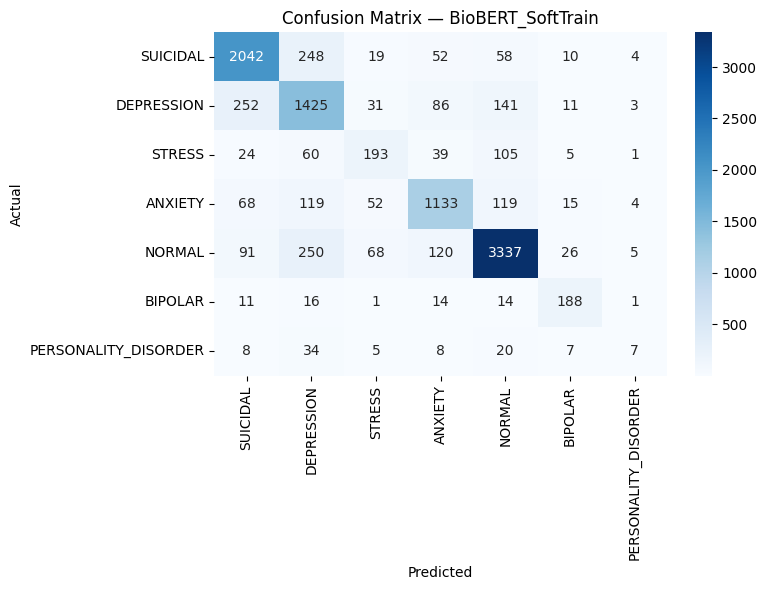

Saved → ./04_SoftLabel_TrainOnly/outputs/BioBERT_SoftTrain_roc_curve.png


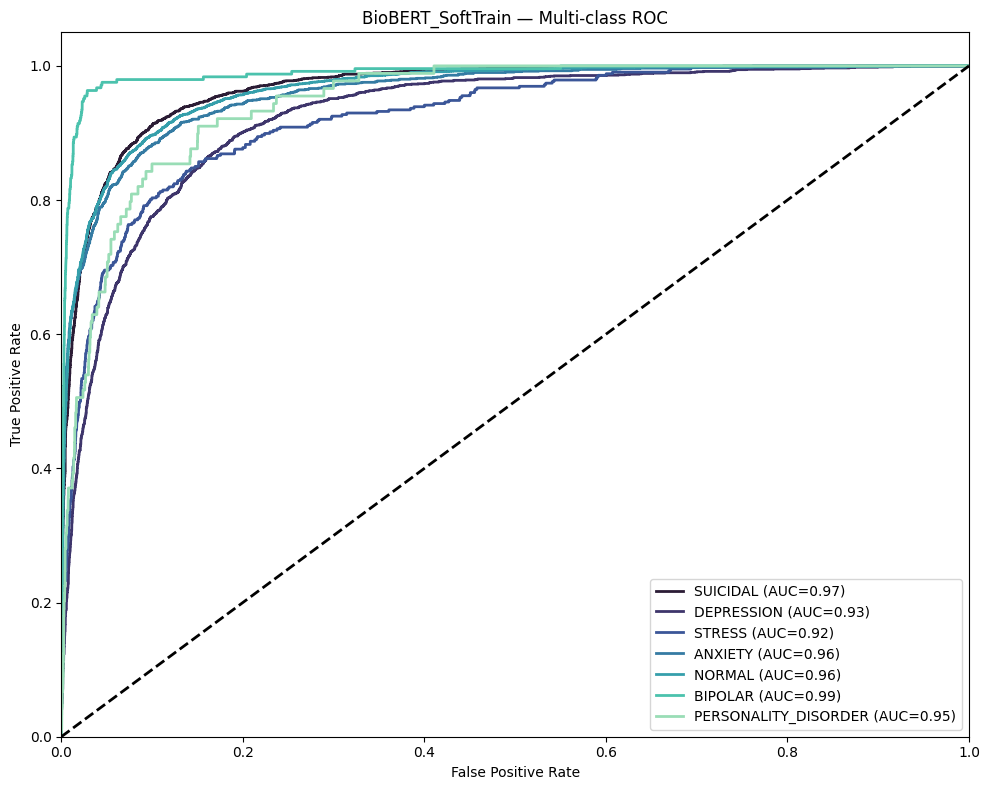

In [27]:
biobert_results = evaluate_with_ci(
    best_biobert, test_loader_biobert, "BioBERT", save_dir=str(OUTPUT_PATH)
)

## 3.6 Save Prediction

In [28]:
df_test_out = df_test[["id", TEXT_COLUMN, "y_hard"]].copy()
df_test_out["albert_pred"] = albert_results["y_pred"]
df_test_out["biobert_pred"] = biobert_results["y_pred"]

for i, name in enumerate(CLASS_NAMES):
    df_test_out[f"albert_p_{name}"] = albert_results["y_prob"][:, i]
    df_test_out[f"biobert_p_{name}"] = biobert_results["y_prob"][:, i]

pred_path = OUTPUT_PATH / "test_predictions_soft_train.csv"
df_test_out.to_csv(pred_path, index=False)
print(f"\nSaved predictions → {pred_path}")

print("\n" + "=" * 60)
print("SUMMARY — 7-Class Soft-Label Train (Mental Health)")
print("=" * 60)
for model_name, results in [("ALBERT", albert_results), ("BioBERT", biobert_results)]:
    print(f"\n{model_name}:")
    print(f"  Weighted F1: {results['f1_weighted']:.4f} "
          f"[{results['f1_ci'][0]:.4f}, {results['f1_ci'][1]:.4f}]")
    if "f1_macro" in results:
        print(f"  Macro F1:    {results['f1_macro']:.4f} "
                f"[{results['f1_macro_ci'][0]:.4f}, {results['f1_macro_ci'][1]:.4f}]")
    print(f"  Macro AUC:   {results['auc_macro']:.4f} "
          f"[{results['auc_ci'][0]:.4f}, {results['auc_ci'][1]:.4f}]")


Saved predictions → ./04_SoftLabel_TrainOnly/outputs/test_predictions_soft_train.csv

SUMMARY — 7-Class Soft-Label Train (Mental Health)

ALBERT:
  Weighted F1: 0.7897 [0.7819, 0.7977]
  Macro F1:    0.6272 [0.6156, 0.6373]
  Macro AUC:   0.9498 [0.9451, 0.9542]

BioBERT:
  Weighted F1: 0.7874 [0.7801, 0.7954]
  Macro F1:    0.6437 [0.6293, 0.6596]
  Macro AUC:   0.9535 [0.9498, 0.9571]
